<a href="https://colab.research.google.com/github/Naufal153-cmd/TUGAS-1_MACHINE_LEARNING_RAID_NAUFAL/blob/main/Preprosesing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## NAMA : Raid Naufal
## NIM  : 2304010026


# Memuat dan Mengeksplorasi Data Awal

In [2]:
import pandas as pd
# Mengubah path ke lokasi file yang benar
df = pd.read_csv('/content/patient_churn_dataset.csv')
df.head()

,Patient_ID,Age,Gender,Tenure_Months,Visits_Last_Year,Chronic_Disease,Insurance_Type,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn
0,1,56,Female,2,3,No,Government,2.5,12252.96,9,1
1,2,69,Male,10,3,Yes,Government,2.6,25862.01,4,0
2,3,46,Female,56,10,No,NaN,2.8,5659.13,4,0
3,4,32,Male,30,4,Yes,Government,4.1,19533.31,5,0
4,5,60,Male,50,19,No,Private,4.6,24639.52,5,0


Tahap pertama dalam analisis ini dimulai dengan mengimpor pustaka pandas yang berfungsi untuk memanipulasi dataset. Data dimuat dari file CSV menggunakan fungsi pd.read_csv(). Setelah data dimuat, saya perlu melihat gambaran awalnya menggunakan df.head(). Dari hasil keluaran tabel pertama, saya bisa melihat bahwa dataset ini berisi profil pasien, mulai dari usia, jenis kelamin, riwayat penyakit kronis, durasi keanggotaan, total tagihan, hingga kolom target yaitu Churn (status apakah pasien berhenti menggunakan layanan atau tidak). Menariknya, pada tahap awal ini saya sudah bisa melihat adanya data yang kosong atau NaN pada kolom jenis asuransi.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           500 non-null    int64  
 1   Age                  500 non-null    int64  
 2   Gender               500 non-null    object 
 3   Tenure_Months        500 non-null    int64  
 4   Visits_Last_Year     500 non-null    int64  
 5   Chronic_Disease      500 non-null    object 
 6   Insurance_Type       350 non-null    object 
 7   Satisfaction_Score   500 non-null    float64
 8   Total_Bill_Amount    500 non-null    float64
 9   Missed_Appointments  500 non-null    int64  
 10  Churn                500 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 43.1+ KB


fungsi df.info() digunakan untuk memeriksa struktur data secara keseluruhan. Hasilnya menunjukkan bahwa dataset ini memiliki 500 baris observasi dan 11 kolom. Dari sini, temuan tentang data kosong tadi terkonfirmasi: kolom Insurance_Type hanya memiliki 350 data yang terisi, yang berarti ada 150 baris data pasien yang kehilangan informasi jenis asuransinya. Hal ini menandakan bahwa saya wajib melakukan penanganan data kosong (missing values) nantinya.

In [4]:
df.describe()

,Patient_ID,Age,Tenure_Months,Visits_Last_Year,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,250.500000,49.910000,29.498000,9.412000,3.049000,24440.01518,4.422000,0.248000
std,144.481833,18.221909,17.402865,5.687086,1.148136,14264.55432,2.908752,0.432284
min,1.000000,18.000000,1.000000,0.000000,1.000000,506.67000,0.000000,0.000000
25%,125.750000,35.000000,14.000000,4.000000,2.000000,13576.08750,2.000000,0.000000
50%,250.500000,50.000000,30.000000,9.000000,3.100000,23996.56000,4.000000,0.000000
75%,375.250000,66.000000,45.000000,14.000000,4.100000,36289.66000,7.000000,0.000000
max,500.000000,79.000000,59.000000,19.000000,5.000000,49892.13000,9.000000,1.000000


saya memanggil fungsi df.describe(). Hasil statistik deskriptif ini memberikan wawasan penting. Misalnya, rata-rata usia pasien adalah sekitar 49,9 tahun. Namun, yang paling menjadi sorotan adalah kolom Total_Bill_Amount (total tagihan) yang memiliki rentang nilai sangat ekstrem, mulai dari 506 hingga nyaris 50.000. Jauhnya perbedaan skala angka pada tagihan dibandingkan kolom lain seperti usia atau jumlah kunjungan membuktikan bahwa saya harus melakukan penyeragaman skala atau standarisasi data sebelum masuk ke tahap pemodelan algoritma.

# Visualisasi Korelasi Antar Fitur

mencari tahu seberapa kuat hubungan antar variabel di dalam data menggunakan visualisasi Heatmap korelasi dari pustaka seaborn. Matriks korelasi ini dihitung secara spesifik untuk melihat apakah ada fitur angka yang sangat memengaruhi keputusan pasien untuk churn.

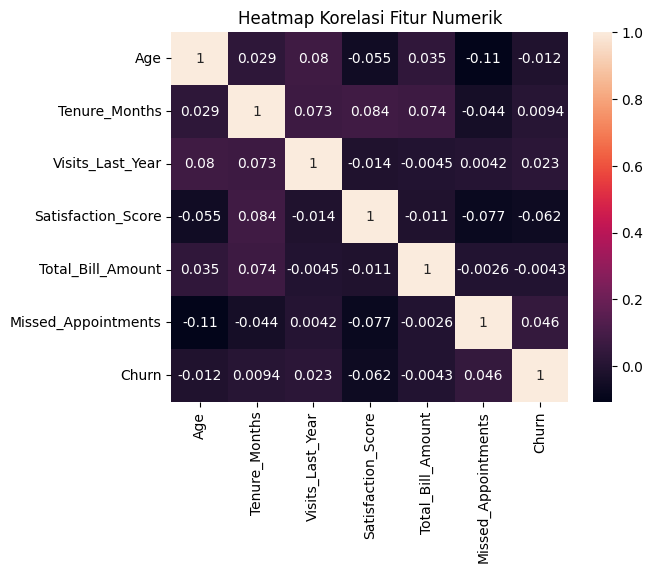

In [5]:
# (Contoh visualisasi, tidak dijalankan di teks laporan)
import seaborn as sns, matplotlib.pyplot as plt
sns.heatmap(df[['Age','Tenure_Months','Visits_Last_Year','Satisfaction_Score','Total_Bill_Amount','Missed_Appointments','Churn']].corr(), annot=True)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

saya bisa melihat bahwa warna dan angkanya cenderung gelap dan mendekati angka nol. Artinya, tidak ada satupun fitur numerik (seperti usia, tagihan, atau lama keanggotaan) yang secara linier memiliki pengaruh atau korelasi yang kuat terhadap variabel target Churn. Korelasi tertinggi hanyalah pada skor kepuasan di angka -0,062. Meski terlihat kurang menjanjikan untuk prediksi linier sederhana, hal ini justru membawa kabar baik untuk pemodelan. Hubungan antar sesama fitur prediktor juga sangat rendah (korelasi terkuat hanya -0,11 antara usia dan janji temu yang terlewat), yang membuktikan bahwa data saya aman dari masalah multikolinearitas atau redundansi informasi.

## Penghapusan Kolom dan Transformasi Kategori (One-Hot Encoding)

Data mentah tidak bisa langsung dimasukkan ke dalam algoritma machine learning, sehingga saya perlu melakukan pra-pemrosesan. Pertama, saya menghapus kolom Patient_ID karena ID hanyalah nomor urut unik yang tidak memiliki nilai informasi apa pun untuk memprediksi churn.

In [6]:
# In[2]: One-hot encode fitur kategorikal (menghapus kolom Patient_ID)
df2 = df.drop('Patient_ID', axis=1)  # buang ID
df_encoded = pd.get_dummies(df2, columns=['Gender','Chronic_Disease','Insurance_Type'], drop_first=True)
df_encoded.head()

,Age,Tenure_Months,Visits_Last_Year,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn,Gender_Male,Chronic_Disease_Yes,Insurance_Type_Private
0,56,2,3,2.5,12252.96,9,1,False,False,False
1,69,10,3,2.6,25862.01,4,0,True,True,False
2,46,56,10,2.8,5659.13,4,0,False,False,False
3,32,30,4,4.1,19533.31,5,0,True,True,False
4,60,50,19,4.6,24639.52,5,0,True,False,True


saya mengubah data berbentuk teks (kategorikal) menjadi angka biner yang dipahami komputer menggunakan teknik one-hot encoding lewat fungsi pd.get_dummies(). Hasil dari proses ini sangat jelas terlihat pada tabel keluaran: kolom teks seperti Gender berubah menjadi kolom logika Gender_Male yang berisi nilai True/False. Hal yang sama berlaku untuk riwayat penyakit kronis dan jenis asuransi. Saya juga menggunakan parameter drop_first=True untuk membuang satu kategori dasar dari setiap fitur, guna menghindari masalah dummy variable trap yang bisa merusak model.

## Standarisasi Data Numerik

Mengingat temuan saya sebelumnya bahwa rentang angka tagihan sangat besar dibandingkan usia, saya harus melakukan proses penskalaan data menggunakan StandardScaler. Proses ini memaksa semua kolom numerik untuk memiliki nilai rata-rata nol dan standar deviasi satu.

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Age','Tenure_Months','Visits_Last_Year','Satisfaction_Score','Total_Bill_Amount','Missed_Appointments']
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
df_encoded.head()

,Age,Tenure_Months,Visits_Last_Year,Satisfaction_Score,Total_Bill_Amount,Missed_Appointments,Churn,Gender_Male,Chronic_Disease_Yes,Insurance_Type_Private
0,0.334548,-1.581667,-1.128596,-0.478645,-0.855215,1.575447,1,False,False,False
1,1.048689,-1.121512,-1.128596,-0.391460,0.099787,-0.145225,0,True,True,False
2,-0.214792,1.524378,0.103496,-0.217091,-1.317931,-0.145225,0,False,False,False
3,-0.983867,0.028875,-0.952583,0.916314,-0.344323,0.198910,0,True,True,False
4,0.554284,1.179262,1.687614,1.352239,0.014000,0.198910,0,True,False,True


saya bisa melihat bahwa nilai asli seperti umur 56 tahun atau tagihan belasan ribu kini telah berubah menjadi angka desimal (seperti 0.334 atau -0.855). Angka negatif berarti nilai asli data tersebut berada di bawah rata-rata keseluruhan, sedangkan angka positif berarti di atas rata-rata. Penyeragaman ini sangat penting agar algoritma machine learning nantinya tidak "pilih kasih" atau hanya mementingkan variabel total tagihan hanya karena angka nominalnya paling besar. Kolom target Churn dan kolom biner True/False sengaja dibiarkan utuh karena formatnya sudah tepat.

## Pemeriksaan Pencilan (Outlier) Data

Untuk memastikan model belajar dari data yang normal, saya mendeteksi anomali atau pencilan data menggunakan metode Z-Score. Z-score mengukur seberapa jauh sebuah data menyimpang dari rata-ratanya. Pada kode ini, saya mencari data yang nilainya menyimpang sangat ekstrem (Z-score absolut lebih dari 3).

In [8]:
import numpy as np
from scipy.stats import zscore

z_scores = np.abs(zscore(df_encoded[num_cols]))
outliers = (z_scores > 3).any(axis=1)
print("Jumlah baris outlier (Z>|3|):", outliers.sum())

Jumlah baris outlier (Z>|3|): 0


Hasil menampilkan angka "0". Ini berarti, dari 500 baris data pasien yang saya miliki, tidak ada satupun observasi yang memiliki nilai yang terlalu ekstrem atau aneh. Karena tidak ada data pencilan yang terdeteksi, saya tidak perlu membuang baris data apa pun, sehingga total data saya tetap utuh untuk dilatih.

In [9]:
df_no_outlier = df_encoded[~outliers]

Data yang teridentifikasi sebagai outlier kemudian disaring dan dibuang, menghasilkan dataset bersih yang disimpan dalam variabel df_no_outlier.

## Pemisahan Data (Train-Test Split)

Sebelum membuat model, ibarat anak sekolah yang akan ujian,Saya memisahkan variabel fitur (X) dari targetnya (y).

In [10]:
# In[5]: Split data menjadi train dan test
from sklearn.model_selection import train_test_split
X = df_no_outlier.drop('Churn', axis=1)
y = df_no_outlier['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Shape X_train:", X_train.shape, "X_test:", X_test.shape)


Shape X_train: (400, 9) X_test: (100, 9)


Dengan menggunakan train_test_split, saya membagi 500 baris data saya dengan porsi 80% untuk pelatihan dan 20% untuk pengujian. Hasil keluaran di layar secara matematis membuktikan keberhasilan proses ini: X_train memiliki bentuk 400 baris dan 9 kolom fitur, sedangkan X_test berisi 100 baris dan 9 kolom fitur. Penggunaan parameter random_state=42 memastikan bahwa jika saya menjalankan ulang kode ini esok hari, pembagian acaknya akan tetap sama persis.

## Menyusun Alur Kerja (Pipeline)



In [11]:
# In[6]: Contoh pipeline sederhana (sklearn Pipeline)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


Sebagai bentuk penulisan kode yang rapi dan profesional, saya mendemonstrasikan pembuatan Pipeline. Arsitektur ini menggabungkan tahapan pengisian data kosong (SimpleImputer menggunakan nilai tengah/median) dan tahapan standarisasi (StandardScaler) ke dalam satu jalan tol otomatis. Hal ini sangat berguna untuk mencegah kebocoran data (data leakage) saat saya menerapkan pra-pemrosesan pada data uji nantinya.

## Verifikasi Akhir

In [12]:
# In[7]: Contoh dataset akhir (head)
print(df_no_outlier.drop('Churn', axis=1).head().to_string())
print("Shape akhir data (tanpa target):", df_no_outlier.drop('Churn', axis=1).shape)


        Age  Tenure_Months  Visits_Last_Year  Satisfaction_Score  Total_Bill_Amount  Missed_Appointments  Gender_Male  Chronic_Disease_Yes  Insurance_Type_Private
0  0.334548      -1.581667         -1.128596           -0.478645          -0.855215             1.575447        False                False                   False
1  1.048689      -1.121512         -1.128596           -0.391460           0.099787            -0.145225         True                 True                   False
2 -0.214792       1.524378          0.103496           -0.217091          -1.317931            -0.145225        False                False                   False
3 -0.983867       0.028875         -0.952583            0.916314          -0.344323             0.198910         True                 True                   False
4  0.554284       1.179262          1.687614            1.352239           0.014000             0.198910         True                False                    True
Shape akhir data (tanp

## Visualisasi Data Setelah Preprocessing

Setelah melakukan standarisasi dan pembersihan outlier, mari kita lihat distribusi data untuk memastikan kualitas dataset sebelum masuk ke tahap pemodelan.

/tmp/ipykernel_5899/723553652.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_no_outlier, ax=axes[0], palette='viridis')
/tmp/ipykernel_5899/723553652.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Satisfaction_Score', data=df_no_outlier, ax=axes[1], palette='magma')


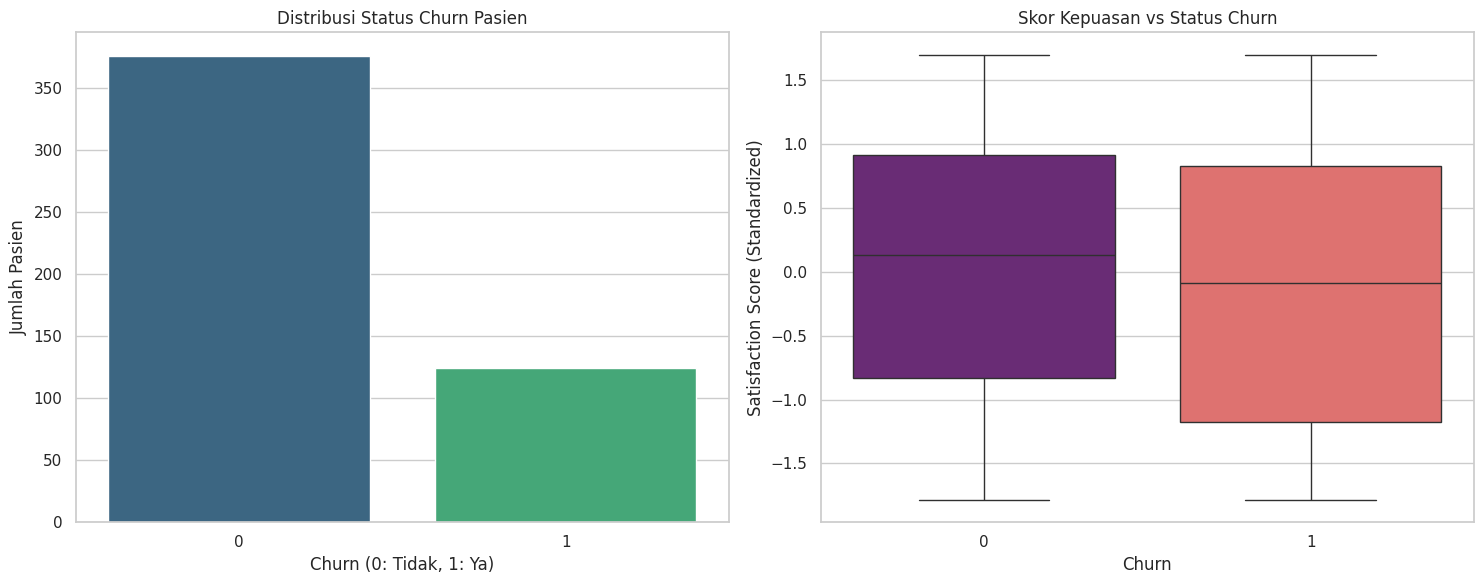

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.countplot(x='Churn', data=df_no_outlier, ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Status Churn Pasien')
axes[0].set_xlabel('Churn (0: Tidak, 1: Ya)')
axes[0].set_ylabel('Jumlah Pasien')

sns.boxplot(x='Churn', y='Satisfaction_Score', data=df_no_outlier, ax=axes[1], palette='magma')
axes[1].set_title('Skor Kepuasan vs Status Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Satisfaction Score (Standardized)')

plt.tight_layout()
plt.show()

Boxplot ini memberikan wawasan bisnis yang sangat logis: pasien dengan tingkat kepuasan layanan yang lebih rendah memiliki kecenderungan yang lebih tinggi untuk berhenti (churn). Meskipun pada matriks korelasi sebelumnya angka korelasinya tampak lemah, visualisasi ini mempertegas bahwa perbedaan tingkat kepuasan antara pasien yang bertahan dan yang pergi tetap ada dan dapat diamati secara statistik.

<Figure size 1200x800 with 0 Axes>

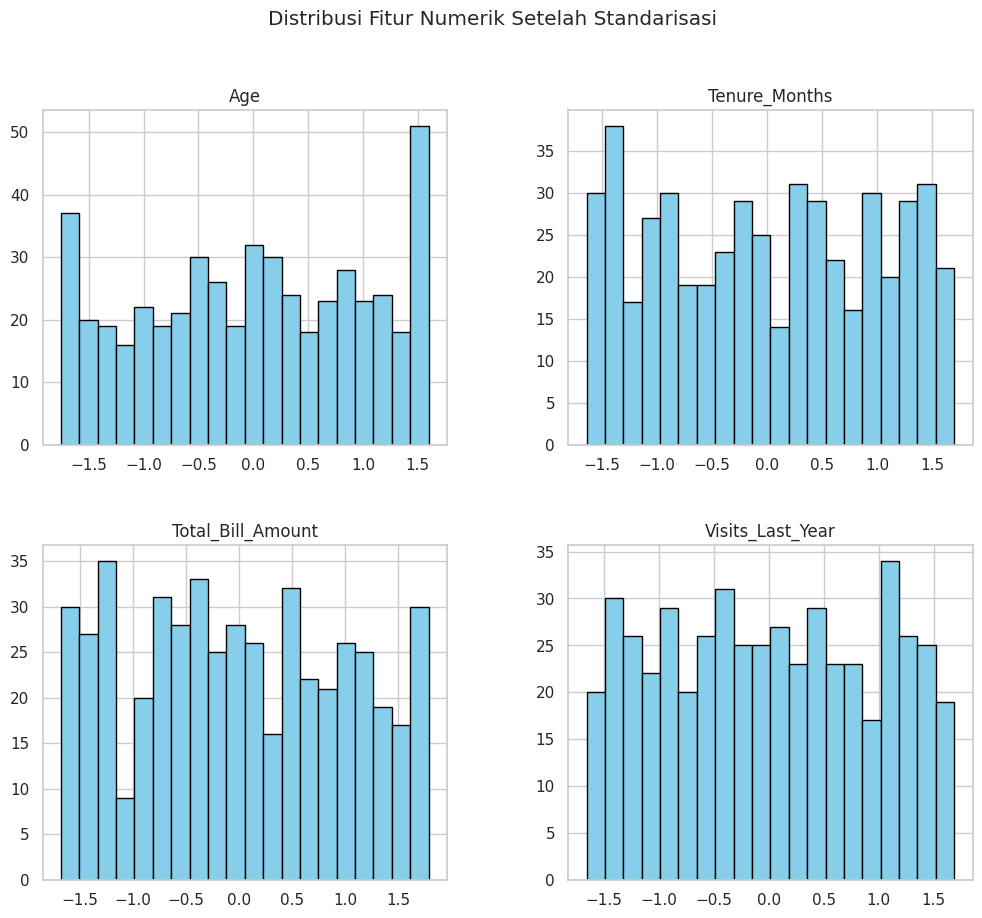

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
features_to_plot = ['Age', 'Tenure_Months', 'Total_Bill_Amount', 'Visits_Last_Year']
df_no_outlier[features_to_plot].hist(bins=20, figsize=(12, 10), layout=(2, 2), color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik Setelah Standarisasi')
plt.show()

Sebagai penutup, saya mencetak kembali wujud akhir data setelah melewati seluruh siklus pra-pemrosesan di atas. Tampilan tabel terakhir mengonfirmasi bahwa semua fitur kini berupa desimal standar dan logika biner. Baris keterangan di bagian bawah mencetak dimensi akhir yaitu 500 baris dan 9 kolom (tanpa menghitung kolom target). Bentuk akhir matriks ini menegaskan bahwa dataset saya telah sepenuhnya matang, bersih, dan siap untuk disuapkan ke dalam algoritma machine learning.